In [1]:
import pandas as pd
import numpy as np
from  sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
import re
from nltk.stem.porter import PorterStemmer


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [33]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [35]:
print (stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [36]:
news_detection=pd.read_csv('/content/drive/MyDrive/train.csv')

In [37]:
news_detection.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [38]:
news_detection.info

<bound method DataFrame.info of           id                                              title  \
0          0  House Dem Aide: We Didn’t Even See Comey’s Let...   
1          1  FLYNN: Hillary Clinton, Big Woman on Campus - ...   
2          2                  Why the Truth Might Get You Fired   
3          3  15 Civilians Killed In Single US Airstrike Hav...   
4          4  Iranian woman jailed for fictional unpublished...   
...      ...                                                ...   
20795  20795  Rapper T.I.: Trump a ’Poster Child For White S...   
20796  20796  N.F.L. Playoffs: Schedule, Matchups and Odds -...   
20797  20797  Macy’s Is Said to Receive Takeover Approach by...   
20798  20798  NATO, Russia To Hold Parallel Exercises In Bal...   
20799  20799                          What Keeps the F-35 Alive   

                                          author  \
0                                  Darrell Lucus   
1                                Daniel J. Flynn   
2                             Consortiumnews.com   
3                                Jessica Purkiss   
4                                 Howard Portnoy   
...                                          ...   
20795                              Jerome Hudson   
20796                           Benjamin Hoffman   
20797  Michael J. de la Merced and Rachel Abrams   
20798                                Alex Ansary   
20799                              David Swanson   

                                                    text  label  
0      House Dem Aide: We Didn’t Even See Comey’s Let...      1  
1      Ever get the feeling your life circles the rou...      0  
2      Why the Truth Might Get You Fired October 29, ...      1  
3      Videos 15 Civilians Killed In Single US Airstr...      1  
4      Print \nAn Iranian woman has been sentenced to...      1  
...                                                  ...    ...  
20795  Rapper T. I. unloaded on black celebrities who...      0  
20796  When the Green Bay Packers lost to the Washing...      0  
20797  The Macy’s of today grew from the union of sev...      0  
20798  NATO, Russia To Hold Parallel Exercises In Bal...      1  
20799    David Swanson is an author, activist, journa...      1  

[20800 rows x 5 columns]>

In [39]:
news_detection.isnull().sum()

,0
id,0
title,558
author,1957
text,39
label,0


In [40]:
news_detection=news_detection.fillna(' ')

In [41]:
x=news_detection.drop(columns = 'label', axis=1)
y=news_detection['label']

In [42]:
print (y)

0        1
1        0
2        1
3        1
4        1
        ..
20795    0
20796    0
20797    0
20798    1
20799    1
Name: label, Length: 20800, dtype: int64


In [43]:
print (x)

          id                                              title  \
0          0  House Dem Aide: We Didn’t Even See Comey’s Let...   
1          1  FLYNN: Hillary Clinton, Big Woman on Campus - ...   
2          2                  Why the Truth Might Get You Fired   
3          3  15 Civilians Killed In Single US Airstrike Hav...   
4          4  Iranian woman jailed for fictional unpublished...   
...      ...                                                ...   
20795  20795  Rapper T.I.: Trump a ’Poster Child For White S...   
20796  20796  N.F.L. Playoffs: Schedule, Matchups and Odds -...   
20797  20797  Macy’s Is Said to Receive Takeover Approach by...   
20798  20798  NATO, Russia To Hold Parallel Exercises In Bal...   
20799  20799                          What Keeps the F-35 Alive   

                                          author  \
0                                  Darrell Lucus   
1                                Daniel J. Flynn   
2                             Consortiu

In [44]:
print (y.size)


20800


In [45]:
print (y)

0        1
1        0
2        1
3        1
4        1
        ..
20795    0
20796    0
20797    0
20798    1
20799    1
Name: label, Length: 20800, dtype: int64


In [46]:
news_detection['content']= news_detection['author']+' '+news_detection['title']

In [47]:
print
news_detection['content']

,content
0,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,Consortiumnews.com Why the Truth Might Get You...
3,Jessica Purkiss 15 Civilians Killed In Single ...
4,Howard Portnoy Iranian woman jailed for fictio...
...,...
20795,Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
20796,"Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma..."
20797,Michael J. de la Merced and Rachel Abrams Macy...
20798,"Alex Ansary NATO, Russia To Hold Parallel Exer..."


In [48]:
prort_stem=PorterStemmer()

In [54]:
def stemming (content):
  stemmed_content=re.sub('[^a-zA-Z]',' ',content)
  stemmed_content=stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[prort_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content=' '.join(stemmed_content)
  return stemmed_content


In [55]:
news_detection['content']=news_detection['content'].apply(stemming)

In [56]:
print (news_detection['content'])

0        darrel lucu hous dem aid even see comey letter...
1        daniel j flynn flynn hillari clinton big woman...
2                   consortiumnew com truth might get fire
3        jessica purkiss civilian kill singl us airstri...
4        howard portnoy iranian woman jail fiction unpu...
                               ...                        
20795    jerom hudson rapper trump poster child white s...
20796    benjamin hoffman n f l playoff schedul matchup...
20797    michael j de la merc rachel abram maci said re...
20798    alex ansari nato russia hold parallel exercis ...
20799                            david swanson keep f aliv
Name: content, Length: 20800, dtype: object


In [57]:
x=news_detection['content'].values
y=news_detection['label'].values


In [58]:
print (x)

['darrel lucu hous dem aid even see comey letter jason chaffetz tweet'
 'daniel j flynn flynn hillari clinton big woman campu breitbart'
 'consortiumnew com truth might get fire' ...
 'michael j de la merc rachel abram maci said receiv takeov approach hudson bay new york time'
 'alex ansari nato russia hold parallel exercis balkan'
 'david swanson keep f aliv']


In [59]:
print (y)

[1 0 1 ... 0 1 1]


In [60]:
vectorizer= TfidfVectorizer()
vectorizer.fit(x)
x=vectorizer.transform(x)


In [61]:
print (x
       )

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 210687 stored elements and shape (20800, 17128)>
  Coords	Values
  (0, 267)	0.2701012497770876
  (0, 2483)	0.36765196867972083
  (0, 2959)	0.24684501285337127
  (0, 3600)	0.3598939188262558
  (0, 3792)	0.27053324808454915
  (0, 4973)	0.23331696690935097
  (0, 7005)	0.2187416908935914
  (0, 7692)	0.24785219520671598
  (0, 8630)	0.2921251408704368
  (0, 8909)	0.36359638063260746
  (0, 13473)	0.2565896679337956
  (0, 15686)	0.2848506356272864
  (1, 1497)	0.2939891562094648
  (1, 1894)	0.15521974226349364
  (1, 2223)	0.3827320386859759
  (1, 2813)	0.19094574062359204
  (1, 3568)	0.26373768806048464
  (1, 5503)	0.7143299355715573
  (1, 6816)	0.1904660198296849
  (1, 16799)	0.30071745655510157
  (2, 2943)	0.3179886800654691
  (2, 3103)	0.46097489583229645
  (2, 5389)	0.3866530551182615
  (2, 5968)	0.3474613386728292
  (2, 9620)	0.49351492943649944
  :	:
  (20797, 3643)	0.2115550061362374
  (20797, 7042)	0.21799048897828685
  (2079

In [91]:
x_train ,x_test , y_train , y_test = train_test_split(x,y , random_state=2, test_size=0.2, stratify=y)

In [92]:
regresorr = LogisticRegression()

In [93]:
regresorr.fit(x_train ,y_train)

LogisticRegression()

In [94]:
x_train_prediction=regresorr.predict(x_train)

In [95]:
train_data_accuarcy=accuracy_score(x_train_prediction,y_train)

TypeError: 'float' object is not callable

In [96]:
del accuracy_score


In [97]:
from sklearn.metrics import accuracy_score


In [98]:
x_train_prediction=regresorr.predict(x_train)
train_data_accuarcy=accuracy_score(x_train_prediction,y_train)

In [102]:
print ( " train_data_accuarcy  = " , (train_data_accuarcy)*100 , "%")

 train_data_accuarcy  =  98.6358173076923 %


In [103]:
x_test_prediction=regresorr.predict(x_test)
tested_data_accuarcy=accuracy_score(x_test_prediction,y_test)

In [104]:
print( " tested_data_accuarcy  = " , (tested_data_accuarcy)*100 , "%")

 tested_data_accuarcy  =  97.90865384615385 %


In [107]:
from sklearn.metrics import r2_score
r2 = r2_score(y_train, x_train_prediction)
print(r2*100)


94.54326134786044


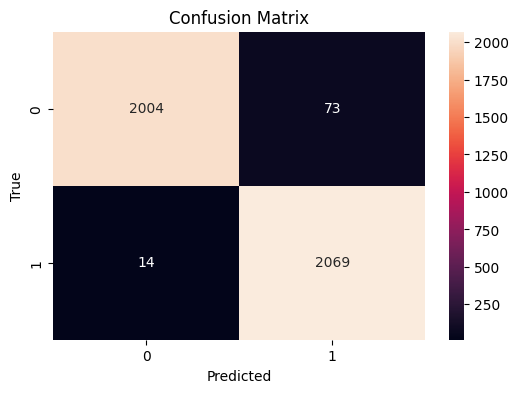

In [108]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, x_test_prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


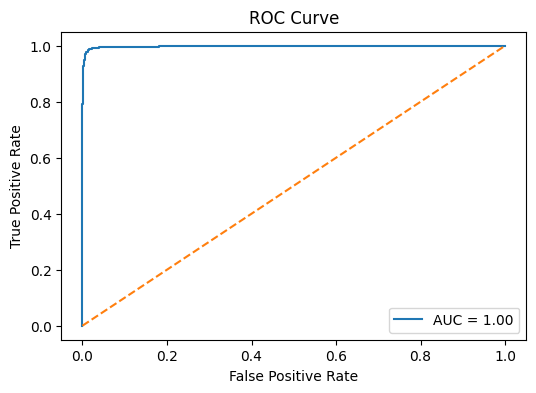

In [109]:
from sklearn.metrics import roc_curve, auc

y_prob = regresorr.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


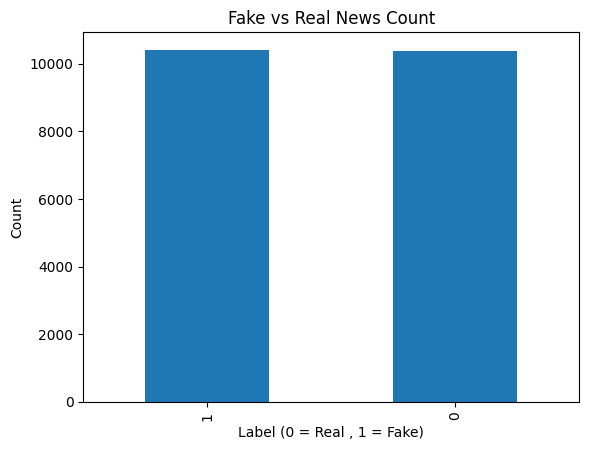

In [110]:
news_detection['label'].value_counts().plot(kind='bar')
plt.title("Fake vs Real News Count")
plt.xlabel("Label (0 = Real , 1 = Fake)")
plt.ylabel("Count")
plt.show()


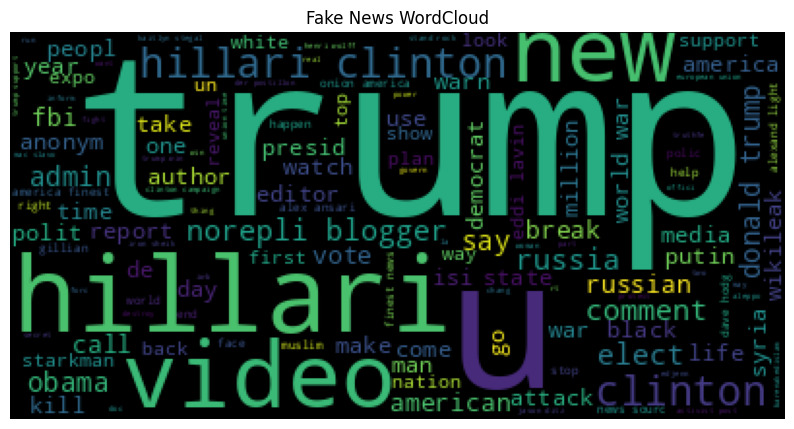

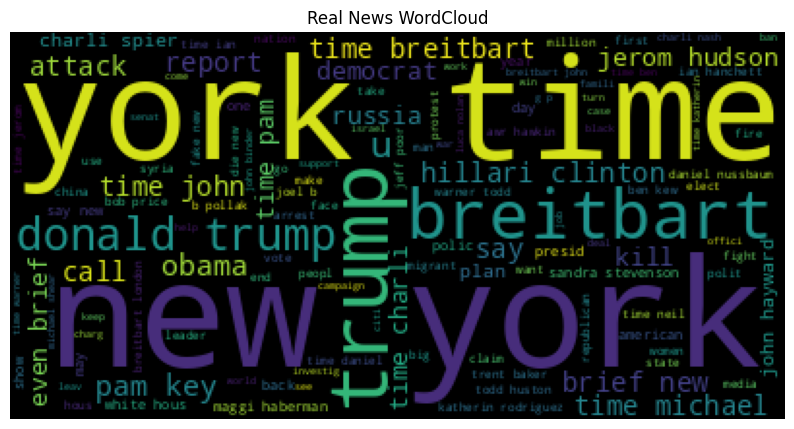

In [111]:
from wordcloud import WordCloud

fake_text = " ".join(news_detection[news_detection['label']==1]['content'])
real_text = " ".join(news_detection[news_detection['label']==0]['content'])

# Fake News Wordcloud
plt.figure(figsize=(10,6))
plt.imshow(WordCloud().generate(fake_text))
plt.title("Fake News WordCloud")
plt.axis("off")
plt.show()

# Real News Wordcloud
plt.figure(figsize=(10,6))
plt.imshow(WordCloud().generate(real_text))
plt.title("Real News WordCloud")
plt.axis("off")
plt.show()
